LOAD DATASET
FEATURE EXTRACTION


C:\Users\acer\anaconda3\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(



KNN EXPERIMENT
K=1, metric=euclidean, acc=0.3300
K=1, metric=manhattan, acc=0.4000
K=1, metric=minkowski, acc=0.3300
K=3, metric=euclidean, acc=0.3500
K=3, metric=manhattan, acc=0.4350
K=3, metric=minkowski, acc=0.3500
K=5, metric=euclidean, acc=0.3700
K=5, metric=manhattan, acc=0.4500
K=5, metric=minkowski, acc=0.3700
K=7, metric=euclidean, acc=0.3650
K=7, metric=manhattan, acc=0.5000
K=7, metric=minkowski, acc=0.3650
K=9, metric=euclidean, acc=0.3850
K=9, metric=manhattan, acc=0.5000
K=9, metric=minkowski, acc=0.3850
K=11, metric=euclidean, acc=0.4000
K=11, metric=manhattan, acc=0.4850
K=11, metric=minkowski, acc=0.4000

SVM EXPERIMENT
linear, C=0.1, gamma=0.001, acc=0.5900
linear, C=0.1, gamma=0.01, acc=0.5900
linear, C=0.1, gamma=0.1, acc=0.5900
linear, C=0.1, gamma=1, acc=0.5900
linear, C=1, gamma=0.001, acc=0.8750
linear, C=1, gamma=0.01, acc=0.8750
linear, C=1, gamma=0.1, acc=0.8750
linear, C=1, gamma=1, acc=0.8750
linear, C=10, gamma=0.001, acc=0.8650
linear, C=10, gamma=0.01,

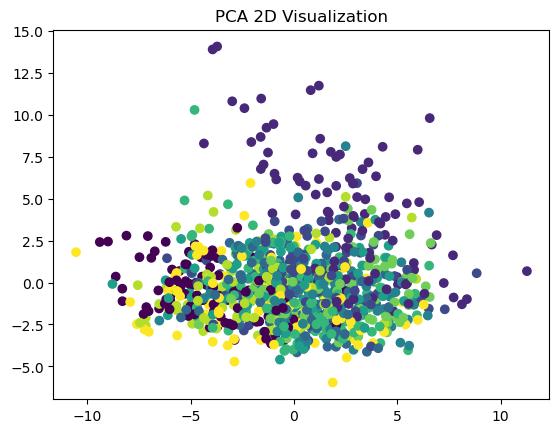


LEARNING CURVE


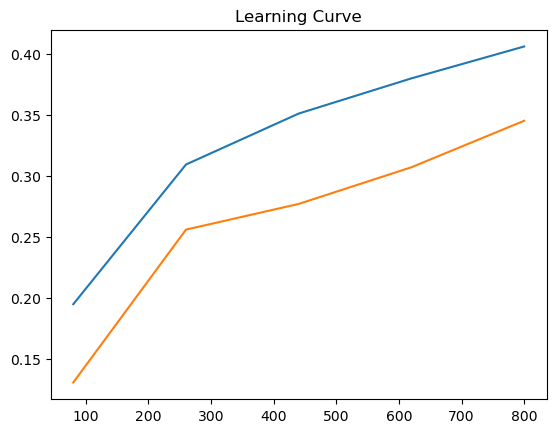

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

from skimage.feature import hog, local_binary_pattern

# =========================================================
# 1. DATASET
# =========================================================
print("LOAD DATASET")
data = load_digits()

X = data.images[:1000]
y = data.target[:1000]

# =========================================================
# 2. FEATURE EXTRACTION (HOG + LBP)
# =========================================================
print("FEATURE EXTRACTION")

def extract_features(images):
    features = []
    for img in images:
        hog_feat = hog(img,
                       orientations=9,
                       pixels_per_cell=(4,4),
                       cells_per_block=(2,2),
                       feature_vector=True)

        lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))

        feat = np.hstack([hog_feat, lbp_hist])
        features.append(feat)

    return np.array(features)

X_feat = extract_features(X)

# =========================================================
# 3. SPLIT DATA
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 4. KNN (k + METRIC)
# =========================================================
print("\nKNN EXPERIMENT")

k_values = [1,3,5,7,9,11]
metrics = ["euclidean", "manhattan", "minkowski"]

knn_results = []

for k in k_values:
    for m in metrics:
        model = KNeighborsClassifier(n_neighbors=k, metric=m)
        start = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start

        start = time.time()
        pred = model.predict(X_test)
        infer_time = time.time() - start

        acc = accuracy_score(y_test, pred)
        knn_results.append((k, m, acc, train_time, infer_time))

        print(f"K={k}, metric={m}, acc={acc:.4f}")

# =========================================================
# 5. SVM (kernel + C + gamma)
# =========================================================
print("\nSVM EXPERIMENT")

kernels = ["linear", "poly", "rbf"]
C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

svm_results = []
best_pred = None
best_acc = 0

for k in kernels:
    for C in C_values:
        for g in gamma_values:

            model = SVC(kernel=k, C=C, gamma=g)

            start = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start

            start = time.time()
            pred = model.predict(X_test)
            infer_time = time.time() - start

            acc = accuracy_score(y_test, pred)

            svm_results.append((k, C, g, acc, train_time, infer_time))

            if acc > best_acc:
                best_acc = acc
                best_pred = pred

            print(f"{k}, C={C}, gamma={g}, acc={acc:.4f}")

# =========================================================
# 6. CONFUSION MATRIX + REPORT
# =========================================================
print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, best_pred))

print(classification_report(y_test, best_pred))

# =========================================================
# 7. ROC & AUC (ONE VS REST)
# =========================================================
print("\nROC AUC")

y_bin = label_binarize(y_test, classes=np.unique(y))
model = SVC(kernel="rbf", C=1, probability=True)
model.fit(X_train, y_train)

y_score = model.predict_proba(X_test)
auc = roc_auc_score(y_bin, y_score, multi_class="ovr")

print("AUC:", auc)

# =========================================================
# 8. CROSS VALIDATION (STRATIFIED)
# =========================================================
print("\nCROSS VALIDATION")

skf = StratifiedKFold(n_splits=5)

model_cv = SVC(kernel="rbf", C=1)
scores = cross_val_score(model_cv, X_feat, y, cv=skf)

print("CV mean:", scores.mean())

# =========================================================
# 9. GRID SEARCH
# =========================================================
print("\nGRID SEARCH")

param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": [0.001, 0.01, 0.1]
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

# =========================================================
# 10. PCA VISUALIZATION (DECISION BOUNDARY)
# =========================================================
print("\nPCA VISUALIZATION")

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_feat)

plt.scatter(X_2d[:,0], X_2d[:,1], c=y)
plt.title("PCA 2D Visualization")
plt.show()

# =========================================================
# 11. LEARNING CURVE
# =========================================================
print("\nLEARNING CURVE")

train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel="rbf", C=1),
    X_feat, y, cv=5
)

plt.plot(train_sizes, np.mean(train_scores, axis=1))
plt.plot(train_sizes, np.mean(test_scores, axis=1))
plt.title("Learning Curve")
plt.show()